# 04 · Comparing inventory policies under Common Random Numbers (CRN)

How do you tell whether policy A *really* beats policy B, when every run is
buffeted by random demand, seasonal swings and supply disruptions? You make the
randomness **identical** and change *only the policy*. That is **Common Random
Numbers (CRN)**: a bit-for-bit reproducible world, so any difference in outcome
is attributable to the decision rule alone — not luck.

This notebook pits the four textbook buyer policies head-to-head on **one shop
node**, on the **same world**, changing nothing but the reorder rule:

| policy | family | trigger | order quantity |
|---|---|---|---|
| `OrderUpToPolicy`        | **(s, S)**     | every tick, when position < s | up to S |
| `ReorderPointPolicy`     | **(s, Q)**     | every tick, when position < s | fixed Q |
| `PeriodicOrderUpToPolicy`| **(R, S)**     | every R ticks                 | up to S |
| `PeriodicReorderPolicy`  | **(R, s, S)**  | every R ticks *and* position < s | up to S |

> New-paradigm note: a setup directory *is* the scenario (the old
> `World`/`world_to_graph` flow is gone). We load one setup, then run it four
> times with a single-node policy override each time.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Hop up to the repo root so `import src...` and relative paths like
# `setups/two_factories_two_shops` resolve no matter where the kernel started.
while not (Path.cwd() / "pyproject.toml").exists():
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
print("cwd:", Path.cwd())

cwd: /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator


## 1 · The world we hold fixed

We use the bundled `two_factories_two_shops` setup — richer than the minimal
chain: **120 ticks**, a single SKU, and two shops that each source from **two
competing factories** (a cheap-but-slow `f-lo` and a pricey-but-fast `f-hi`).
That multi-supplier contention makes the routing decision — and therefore the
policy — actually *matter*.

Our comparison node is **`shop-1`**. Everything else (`world_seed`, market,
disruptions, every node's initial inventory and cash, the other shop's policy)
stays bit-identical across all four runs.

In [2]:
from src.sim.setup_io import load_setup

scenario = load_setup("setups/two_factories_two_shops")
scenario.summary_df().T

,0
n_steps,120
start_date,2024-01-01 00:00:00
world_seed,42
n_products,1
n_nodes,6
n_DemandSinkNode,2
n_FactoryNode,2
n_IntermediateNode,2


In [3]:
display(scenario.nodes_df())
display(scenario.edges_df())

,node_id,node_type,region,init_seed,policy_class
0,f-lo,FactoryNode,US,3566192719,StaticFactoryPolicy
1,f-hi,FactoryNode,US,739400997,StaticFactoryPolicy
2,shop-1,IntermediateNode,US,98739437,OrderUpToPolicy
3,shop-2,IntermediateNode,US,820177096,OrderUpToPolicy
4,sink-1,DemandSinkNode,US,3754311622,DefaultDemandSinkPolicy
5,sink-2,DemandSinkNode,US,1623657135,DefaultDemandSinkPolicy


,supplier_id,buyer_id,default_lead_time
0,f-lo,shop-1,4
1,f-hi,shop-1,2
2,f-lo,shop-2,4
3,f-hi,shop-2,2
4,shop-1,sink-1,1
5,shop-2,sink-2,1


`shop-1` is supplied by **both** factories: `f-lo` at lead-time 4 and `f-hi`
at lead-time 2. When we build a policy via the registry below, it injects the
*mean* upstream lead time (round((4+2)/2) = 3 ticks) as the policy's
`delivery_lag`, plus the shop's `unit_cost` proxy — facts the textbook math
needs but that don't belong in the policy's hyperparameters.

In [4]:
shop_ni = next(ni for ni in scenario.nodes if type(ni.node).__name__ == "IntermediateNode" and ni.node.id == "shop-1")
shop = shop_ni.node
print("comparison node :", shop.id)
print("carried products:", list(shop.list_prices.keys()))
print("list prices     :", shop.list_prices)
print("opening cash    :", shop.cash)
print("suppliers       :", [e.supplier_id for e in scenario.edges if e.buyer_id == shop.id])

comparison node : shop-1
carried products: ['P0000']
list prices     : {'P0000': 12.0}
opening cash    : 1000.0
suppliers       : ['f-lo', 'f-hi']


### Warm start: every shop opens at 40% of capacity

A reorder rule's first job is just to *refill* — so if every run starts on an
empty shelf, the opening ticks measure "how fast does the policy dig out of a
hole" rather than steady-state quality. To compare the rules on equal, settled
footing we give each shop a **warm start**: initial on-hand stock set to **40%
of its storage capacity** (split evenly across carried products).

We do this **once on the scenario**, before any run. The `Runner` deep-copies
each node per run, so all four policies inherit the *identical* opening
inventory — CRN is preserved.

In [5]:
# Seed every shop with a warm start: 40% of its storage capacity, split evenly
# across the products it carries. Done once on the scenario — the Runner
# deep-copies each node per run, so all four policies begin from the *same*
# non-empty inventory (still pure CRN). Without this, the first ~lead-time ticks
# are an empty-shelf transient that muddies the policy comparison.
INITIAL_FILL = 0.40

for ni in scenario.nodes:
    n = ni.node
    if type(n).__name__ != "IntermediateNode" or not n.carried_products:
        continue
    per_product = int(INITIAL_FILL * float(n.capacity) / len(n.carried_products))
    n.inventory = {pid: per_product for pid in n.carried_products}
    print(f"{n.id:8s} capacity={n.capacity:>5}  initial inventory -> {n.inventory}")

shop-1   capacity=  300  initial inventory -> {'P0000': 120}
shop-2   capacity=  300  initial inventory -> {'P0000': 120}


## 2 · Wiring four correctly-injected policies

The textbook constructors need *injected facts* (`delivery_lag`, `unit_cost`,
`list_price_out`) that depend on the node and its edges. The clean route is the
**registry**: `build_policy(name, params, node=..., edges=..., policy_seed=...)`
resolves the class, injects those facts, and splats the remaining `params` as
hyperparameters. We pass `params` carrying *only* true knobs.

The hyperparameters we chose (deliberately modest, comparable across families):

| policy | name | params |
|---|---|---|
| (s, S)     | `order_up_to`          | `cover_horizon_ticks=10` |
| (s, Q)     | `reorder_point`        | `cover_horizon_ticks=10, Q=30` |
| (R, S)     | `periodic_order_up_to` | `cover_horizon_ticks=10, review_interval=7` |
| (R, s, S)  | `periodic_reorder`     | `cover_horizon_ticks=10, review_interval=7` |

`cover_horizon_ticks=10` (the EOQ-style cover horizon) is shared so the families
differ only in *trigger/quantity logic*. We give every policy the same
`policy_seed` so even the tie-breaking RNG is held constant — pure CRN.

In [6]:
from src.sim.policy_registry import build_policy, list_policy_names

print("registry names:", list_policy_names())

POLICY_SEED = 123
LIST_PRICE_OUT = float(shop.list_prices["P0000"])

policy_specs = {
    "OrderUpToPolicy (s,S)":      ("order_up_to",          {"cover_horizon_ticks": 10}),
    "ReorderPointPolicy (s,Q)":   ("reorder_point",        {"cover_horizon_ticks": 10, "Q": 30}),
    "PeriodicOrderUpTo (R,S)":    ("periodic_order_up_to", {"cover_horizon_ticks": 10, "review_interval": 7}),
    "PeriodicReorder (R,s,S)":    ("periodic_reorder",     {"cover_horizon_ticks": 10, "review_interval": 7}),
}

def make_policy(name, params):
    p = dict(params)
    p["list_price_out"] = LIST_PRICE_OUT   # advertise the same downstream price
    return build_policy(name, p, node=shop, edges=scenario.edges, policy_seed=POLICY_SEED)

policies = {label: make_policy(name, params) for label, (name, params) in policy_specs.items()}
for label, pol in policies.items():
    print(f"{label:28s} -> {type(pol).__name__:24s} lag={pol.delivery_lag} cover={pol.cover_horizon_ticks}")

registry names: ['default_demand_sink', 'order_up_to', 'periodic_order_up_to', 'periodic_reorder', 'reorder_point', 'single_supplier', 'static_factory']
OrderUpToPolicy (s,S)        -> OrderUpToPolicy          lag=3 cover=10
ReorderPointPolicy (s,Q)     -> ReorderPointPolicy       lag=3 cover=10
PeriodicOrderUpTo (R,S)      -> PeriodicOrderUpToPolicy  lag=3 cover=10
PeriodicReorder (R,s,S)      -> PeriodicReorderPolicy    lag=3 cover=10


## 3 · Run the same world four times — swapping only `shop-1`'s policy

`Runner(scenario, policy_overrides={node_id: policy})` replaces exactly one
node's policy and leaves the rest of the scenario untouched. Because the world
RNG is seeded from `scenario.world_seed`, the market draws, disruption rolls and
every other node behave **identically** in all four runs. The only moving part
is `shop-1`'s reorder rule.

In [7]:
from src.sim.runner import Runner
from src.sim.inspect import node_timeseries_df, node_equity

runs = {}        # label -> run_log
shop_ts = {}     # label -> shop-1 timeseries (sorted by tick)
for label, pol in policies.items():
    rl = Runner(scenario, policy_overrides={"shop-1": pol}).run()
    runs[label] = rl
    ts = node_timeseries_df(rl, scenario)
    shop_ts[label] = ts[ts.node_id == "shop-1"].sort_values("tick").reset_index(drop=True)

print("ran", len(runs), "policies x", scenario.n_steps, "ticks on a bit-identical world")

ran 4 policies x 120 ticks on a bit-identical world


### CRN sanity check — the rest of the world really is identical

If CRN holds, the **market demand** series (a world-level signal) must be
byte-for-byte identical across all four runs. We confirm it before trusting any
comparison.

In [8]:
from src.sim.inspect import global_timeseries_df

gframes = {label: global_timeseries_df(rl) for label, rl in runs.items()}
demand_cols = [c for c in next(iter(gframes.values())).columns if c.startswith("market_demand")]
ref = gframes["OrderUpToPolicy (s,S)"][demand_cols]
all_identical = all(g[demand_cols].equals(ref) for g in gframes.values())
print("market demand identical across all four runs:", all_identical)

market demand identical across all four runs: True


## 4 · Per-policy scorecard

For `shop-1` we compute three comparable metrics:

- **profit per opening dollar** — `(final_cash - opening_cash) / opening_cash`.
  Normalising by opening cash makes it a clean return-on-capital number.
- **availability** — fraction of ticks the shop held `inventory_total > 0`
  (a service proxy: can it serve demand at all?).
- **mean inventory held** — average on-hand units (the carrying-cost burden).

Cash comes from `node_timeseries_df`; we read the configured opening cash from
the node (`shop.cash`).

In [9]:
OPENING_CASH = float(shop.cash)

rows = []
for label, ts in shop_ts.items():
    final_cash = float(ts.cash.iloc[-1])
    profit = final_cash - OPENING_CASH
    rows.append({
        "policy": label,
        "opening_cash": OPENING_CASH,
        "final_cash": final_cash,
        "net_profit": profit,
        "profit_per_dollar": profit / OPENING_CASH,
        "availability": float((ts.inventory_total > 0).mean()),
        "mean_inventory": float(ts.inventory_total.mean()),
    })

scorecard = (
    pd.DataFrame(rows)
    .sort_values("profit_per_dollar", ascending=False)
    .reset_index(drop=True)
)
scorecard

,policy,opening_cash,final_cash,net_profit,profit_per_dollar,availability,mean_inventory
0,"PeriodicOrderUpTo (R,S)",1000.0,12390.0,11390.0,11.390,0.991667,89.008333
1,"OrderUpToPolicy (s,S)",1000.0,12040.0,11040.0,11.040,0.941667,71.350000
2,"ReorderPointPolicy (s,Q)",1000.0,10048.0,9048.0,9.048,0.616667,13.758333
3,"PeriodicReorder (R,s,S)",1000.0,9843.0,8843.0,8.843,0.791667,65.816667


### Add a downstream service proxy: sink fill

The shop only earns when its sink can buy. As an independent service signal we
also look at **`sink-1`'s** mean inventory across each run — a higher floor of
sink stock means the shop kept it supplied. (Same CRN logic: the sink's demand
draws are identical; only fulfilment differs.)

In [10]:
sink_rows = []
for label, rl in runs.items():
    ts = node_timeseries_df(rl, scenario)
    sink = ts[ts.node_id == "sink-1"].sort_values("tick")
    sink_rows.append({
        "policy": label,
        "sink_mean_inventory": float(sink.inventory_total.mean()),
        "sink_availability": float((sink.inventory_total > 0).mean()),
    })
sink_service = pd.DataFrame(sink_rows)
sink_service

,policy,sink_mean_inventory,sink_availability
0,"OrderUpToPolicy (s,S)",0.0,0.0
1,"ReorderPointPolicy (s,Q)",0.0,0.0
2,"PeriodicOrderUpTo (R,S)",0.0,0.0
3,"PeriodicReorder (R,s,S)",0.0,0.0


## 5 · Visual comparison

### Profit-per-dollar and availability, side by side
The left bar is return on opening capital; the right is the in-stock service
proxy. A good policy pushes both up — but watch for the tension: chasing
availability usually means carrying (and paying for) more inventory.

/var/folders/jn/d71y4fj53t7bj2r0q2xhvqrc0000gn/T/ipykernel_62532/1701325133.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=20, ha="right")
/var/folders/jn/d71y4fj53t7bj2r0q2xhvqrc0000gn/T/ipykernel_62532/1701325133.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=20, ha="right")


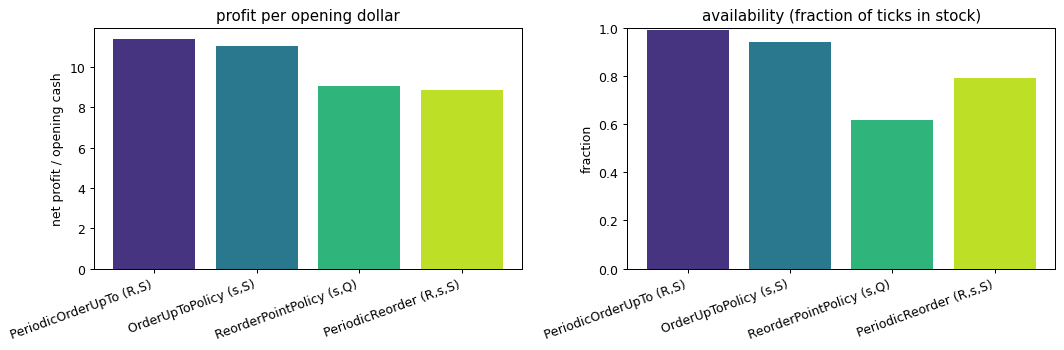

In [11]:
order = scorecard["policy"].tolist()
colors = plt.cm.viridis([0.15, 0.4, 0.65, 0.9])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(order, scorecard["profit_per_dollar"], color=colors)
axes[0].set_title("profit per opening dollar"); axes[0].set_ylabel("net profit / opening cash")
axes[0].axhline(0, color="k", lw=0.6)

avail = scorecard.set_index("policy")["availability"].reindex(order)
axes[1].bar(order, avail, color=colors)
axes[1].set_title("availability (fraction of ticks in stock)"); axes[1].set_ylabel("fraction")
axes[1].set_ylim(0, 1)

for ax in axes:
    ax.set_xticklabels(order, rotation=20, ha="right")
plt.tight_layout(); plt.show()

### Cash trajectory — one line per policy (overlay)
Same world, four reorder rules. Divergence is 100% policy-attributable.

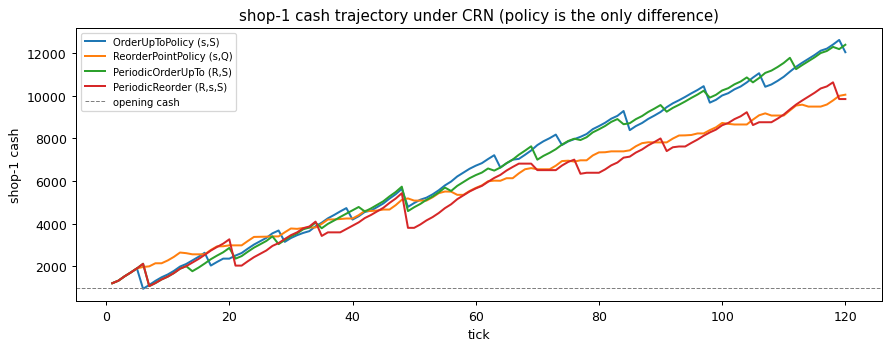

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, ts in shop_ts.items():
    ax.plot(ts.tick, ts.cash, label=label, lw=1.6)
ax.axhline(OPENING_CASH, color="grey", ls="--", lw=0.8, label="opening cash")
ax.set_xlabel("tick"); ax.set_ylabel("shop-1 cash")
ax.set_title("shop-1 cash trajectory under CRN (policy is the only difference)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Inventory trajectory — the carrying-cost story
The (R, …) periodic policies sawtooth (bulk top-ups every 7 ticks); the
continuous (s, S)/(s, Q) rules ride a smoother band. Higher plateaus mean more
capital tied up in stock.

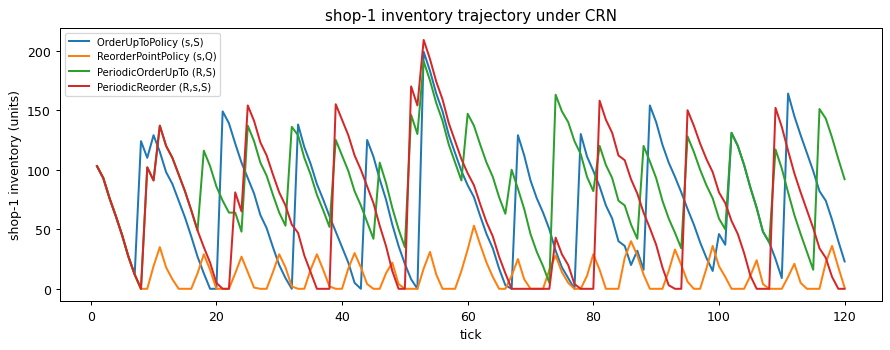

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, ts in shop_ts.items():
    ax.plot(ts.tick, ts.inventory_total, label=label, lw=1.6)
ax.set_xlabel("tick"); ax.set_ylabel("shop-1 inventory (units)")
ax.set_title("shop-1 inventory trajectory under CRN")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 6 · Ranked summary & takeaways

The full scorecard, ranked by profit per opening dollar, joined with the sink
service proxy.

In [14]:
summary = scorecard.merge(sink_service, on="policy").sort_values(
    "profit_per_dollar", ascending=False
).reset_index(drop=True)
summary

,policy,opening_cash,final_cash,net_profit,profit_per_dollar,availability,mean_inventory,sink_mean_inventory,sink_availability
0,"PeriodicOrderUpTo (R,S)",1000.0,12390.0,11390.0,11.390,0.991667,89.008333,0.0,0.0
1,"OrderUpToPolicy (s,S)",1000.0,12040.0,11040.0,11.040,0.941667,71.350000,0.0,0.0
2,"ReorderPointPolicy (s,Q)",1000.0,10048.0,9048.0,9.048,0.616667,13.758333,0.0,0.0
3,"PeriodicReorder (R,s,S)",1000.0,9843.0,8843.0,8.843,0.791667,65.816667,0.0,0.0


In [15]:
# Persist the comparison artifacts (gitignored demo output).
out_dir = Path("data/notebook_demos/04")
out_dir.mkdir(parents=True, exist_ok=True)
summary.to_csv(out_dir / "policy_comparison.csv", index=False)
print("wrote:", out_dir / "policy_comparison.csv")

wrote: data/notebook_demos/04/policy_comparison.csv


**Reading the results**

- **CRN is the whole point.** Because the market-demand check passed (identical
  across runs), every gap between the lines above is caused by the reorder rule
  — never by a lucky or unlucky world. That is what lets you rank policies
  honestly on a stochastic simulator.
- **Tradeoff to watch:** profit-per-dollar and availability pull in opposite
  directions through *inventory*. A policy can buy near-perfect availability by
  hoarding stock, but that capital sits idle and drags the return. The best
  policy is the one highest on the profit axis *while* keeping availability
  acceptable — read the two bar charts together, not apart.
- **Continuous vs. periodic:** the every-tick (s, S)/(s, Q) rules react fast and
  hold a tighter inventory band; the periodic (R, …) rules top up in bursts,
  trading responsiveness for fewer, larger orders (visible as the sawtooth).
- **Want better numbers?** These are sensible-but-untuned hyperparameters.
  Notebook **05** hands the same comparison to Optuna to *tune* a policy, and
  **06** trains a PPO agent to beat the textbook baseline.